## UNet Ablation Comparisons (image)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/UNet Testing Template src/')
import src.training.metrics as m
print(m)

<module 'src.training.metrics' from '/content/drive/MyDrive/UNet Testing Template src/src/training/metrics.py'>


In [3]:
# standard imports
import os
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torchvision.transforms as transforms

from google.colab import files
from PIL import Image
import io

# LIST OF MODELS

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
from src.evaluation.visualization import ModelEntry

# 1) Instantiate your models (outside), exactly as you train them:
from src.models.ablations.unet_res2net50_cbam_hasskip_msu import HybridUNetMDFI
from src.models.blocks.res2net_backbone_adapter import Res2NetBackbone
from src.models.unet_cbam_res2net50 import UNet_Res2Net50
from src.models.blocks.cbam import CBAM
from src.models.unet import UNet
from src.models.unet_msu import UNetMSU
from src.models.unet_cbam import UNet as UNet_CBAM
from src.models.unet_res2net50 import UNet_Res2Net50 as UNet_R2N50
from src.models.ablations.unet_has_skip import UNet_HAS
from src.models.ablations.unet_hasskip_msu import UNet_HASSkip_MSU

backbone = Res2NetBackbone(in_ch=1)

models = [
    ModelEntry("HybridUNetMDFI",
       model = HybridUNetMDFI(backbone=backbone, dec_channels=[512,256,128,64], out_channels=1),
       pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_res2net50_cbam_hasskip_msu.pth",
       threshold=0.5, device=device),
    #ModelEntry("UNet_Res2Net50+CBAM",
     #   model=UNet_Res2Net50(in_ch=1, out_ch=1, baseWidth=26, scale=4, cbam_cls=CBAM, cbam_reduction=16),
      #  pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_cbam_res2net50.pth",
       # threshold=0.5),
    ModelEntry("UNet (vanilla)",
        model=UNet(),
        pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet.pth"),
    ModelEntry("UNet+MSU",
        model=UNetMSU(),
        pth="/content/drive/MyDrive/UNet Testing Template src/pth/msu_unet_model.pth"),
    ModelEntry("UNet+CBAM",
        model=UNet_CBAM(),
        pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_cbam.pth"),
    ModelEntry("UNet_Res2Net50",
        model=UNet_R2N50(),
        pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_res2net50.pth"),
    ModelEntry("UNet_HAS",
        model=UNet_HAS(),
        pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_hasskip.pth"),
    #ModelEntry("UNet_HASSkip_MSU",
     #   model=UNet_HASSkip_MSU(in_channels=1, out_channels=1),
      #  pth="/content/drive/MyDrive/UNet Testing Template src/pth/unet_hasskip_msu.pth"),
]



# DataLoaders

In [ ]:
# DATASET directories
# DRIVE
data_dir = "/content/drive/MyDrive/Retinal_Vessel_Segmentation_Datasets/DRIVE/"
#data_dir = "/content/drive/MyDrive/Retinal_Vessel_Segmentation_Datasets/STARE/"

from src.data.prepare_dataset import build_pairs_for_split
from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

train_pairs = build_pairs_for_split(dataset_root=data_dir, split="training")
val_pairs = build_pairs_for_split(dataset_root=data_dir, split="test")

train_loader, test_loader = make_loaders(
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    image_size=512,
    batch_size=2,
    num_workers=0,           # keep 0 in notebooks (Windows)
    seed=1337,
    strict_fov=True,
    augs_train=get_train_augs(512),
    augs_val=get_val_augs(512),
)


# Visualize

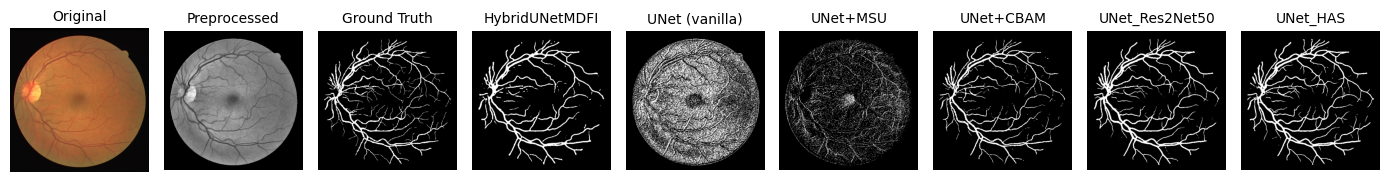

In [19]:
#from src.evaluation.visualization import visualize_models_from_loader


visualize_models_from_loader(
    models=models,
    dataloader=test_loader,
    n_rows=1,
    device=device
)